# BIOMEDIN 260/RAD260 🩻 | A2 - Semantic Segmentation with CNNs

Welcome to the second assignment of Biomedin 260/RAD260!

## Group Work 👥

Before we go any further: we encourage teamwork, and you can work by yourself or in pairs (2 people working together equally and submitting one notebook for the both of you). Who said radiology had to be lonely?

**Person 1:**

<span style="color:orange">YOUR NAME HERE</span>

**Person 2:**

<span style="color:orange">YOUR NAME HERE</span>

## Background

Computer vision encompasses a spectrum of tasks that vary in complexity and granularity. Each task serves distinct purposes in image analysis and interpretation. Let's take a look at the image below to get a sense of the differences between the most common tasks:

![cs231n_vision_tasks](https://i.loli.net/2017/09/12/59b6d0529299e.png)
> Image Credit: CS231N


- `Image Classification` assigns a single class label to an entire image, providing a broad categorization of the image content. When combined with `Localization`, the specific location of the primary object in the image is identified using bounding boxes.

- `Semantic Segmentation` operates at a pixel level, assigning class labels to each individual pixel in an image. This creates a detailed map that precisely delineates different regions or structures.

- `Object Detection` combines localization and classification to identify and categorize multiple object instances within a single image.

- `Instance Segmentation` represents the most detailed analysis, differentiating between individual instances of the same class while providing pixel-level segmentation for each instance.



### Our goal in this assignment 🎯
In this assignment, you will implement a `semantic segmentation` model to delineate tumors in medical images. Our implementation will be based on the `U-Net` architecture, which is a popular choice for semantic segmentation tasks.

## Environment Set Up ⚙️
To set up this ipynb in Google Colab, follow the instructions bellow.

### Compute Access 💻

Training a neural network requires us to compute a large number of calculations. Instead of performing these calculations on a CPU sequentially, we can use a graphics processing unit (GPU) to perform them in parallel. Google Colab provides free access to a GPU for all users.

To enable GPU access, follow the following instructions:
1. Open this ipynb in Google Colab
2. Near the top right hand corner of the Colab interface, look for the `Dropdown` menu next to a button that says `Connect`
3. Within the dropdown menu, select the option `Change runtime type`
4. You should see a new dialog box open up. Under the Hardware Accelerator section, select the option `T4 GPU` and press `Save`
5. Finally, click on the `Connect` button to enable GPU access.


> `Important note`: As a free resource, Google Colab GPU access is somewhat limited. To avoid hitting time limits, you should disconnect from the GPU whenever you are not working on this assignment. To do this, select the drop down menu again and select the option `Disconnect and delete runtime`. Your saved work in this ipynb will not be impacted, but this will free the GPU resource so that other Colab users can access it.

### Import dependencies 📦
Let's start by importing the necessary libraries. Run the following cell to import the dependencies.

In [1]:
# NOTE: You do not need to implement any code in this cell, it is provided for you!
import os

import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

import nibabel as nib
import matplotlib.pyplot as plt

from torchvision.models import vgg16_bn
from torch import optim

from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import os
from IPython.display import display, Javascript
import tensorboard as tb
from typing import Union

In [2]:
# This cell will check to see if you have access to a GPU
# NOTE: You do not need to implement any code in this cell, it is provided for you!
if torch.cuda.is_available():
  print("The GPU is connected! :)")
else:
  print("The GPU is not connected :(")

The GPU is not connected :(


### Data Access 💽

#### BraTS 2023 🧠
The BraTS 2023 dataset (Brain Tumor Segmentation dataset for 2023) is part of a series of datasets and challenges focused on the evaluation of state-of-the-art methods for the segmentation of brain tumors in magnetic resonance imaging (MRI) scans. These datasets have been released annually as part of the BraTS challenge, which is a competition held in conjunction with a major medical imaging conference (MICCAI).

BraTS includes multi-institutional pre-operative MRI scans of gliomas, which are common types of brain tumors. These tumors vary greatly in shape, size, and location, making them a complex target for segmentation algorithms.

#### Accessing the data
For this assignment, BIOMEDIN 260 course staff has prepared and preprocessed a subset of the BraTS 2023 dataset for you to utilize. Rather than downloading this dataset (which is very large!) we recommend accessing the dataset in this Google Colab by adding a shortcut!
Google Drive Folder: [BMI260_A2_BraTS](https://drive.google.com/drive/folders/1Jc8AuLI5RCXXjol8L2mq434OY5ZlP6H0?usp=drive_link)



1. Click on the link above to open the [BMI260_A2_BraTS Google Drive Folder](https://drive.google.com/drive/folders/1Jc8AuLI5RCXXjol8L2mq434OY5ZlP6H0?usp=drive_link)

2. Click on the drop down menu next to the `BMI260_A2_BraTS` folder name and mouse over the `Organize` option.

3. Select the option `Add Shortcut` within the `Organize` menu

4. A dialog box should appear asking where you want to save the shortcut to this folder within your Google Drive. We recommend saving it to your drive by selecting `All Locations` > `My Drive` and clicking `Add`.

> NOTE: If you have any trouble setting up the shortcut and accessing the images, you can also download the data to your Stanford University Google Drive.



In [3]:
# NOTE: You do not need to implement any code in this cell, it is provided for you!
# Now we must connect this colab session to your Google Drive to access the images!
# - Run this cell to make your Google Drive Accessible
# - When prompted for Google Drive access, press 'Allow'


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# In Colab, we can run bash commands utilizing the "!" character. Let's see what our current working directory is
!pwd

/content


In [5]:
# We can also list which directories are present
!ls

drive  sample_data


In [6]:
# If you saved the data as a shortcut to your drive, it should be at the following path:
# - NOTE: You will need to change this path if you utilized a different method or saved the shortcut at a different location
DATA_PATH = "drive/MyDrive/BMI260_A2_BraTS/"

In [7]:
# You should see the folders 'train' and 'val' in the DATA_PATH directory if they were saved correctly
if "train" in os.listdir(DATA_PATH) and "val" in os.listdir(DATA_PATH):
  print("Data successfully set up!")
else:
  print("Unable to find train and validation folders")

print(f"Contents of current DATA_PATH: {os.listdir(DATA_PATH)}")

Data successfully set up!
Contents of current DATA_PATH: ['train', 'val']


# 1 | Getting familar with the data

The first step in any analysis task is to visualize the data. Let's take a look at our images and masks!

The actual BraTS dataset is a 3D dataset, but for this assignment we have preprocessed the data to only provide one 2D slice from each patient. The dataset is organized as follows:
```bash
DATA_PATH/
├── train/
│   ├── BraTS-GLI-00725-000/  # Each patient has a unique identifier
│   │   ├── t1n.nii.gz        # Non-contrast T1-weighted image
│   │   ├── t1c.nii.gz        # Contrast-enhanced T1-weighted image
│   │   ├── t2f.nii.gz        # Flair-weighted T2-weighted image
│   │   ├── t2w.nii.gz        # T2-weighted image
│   │   └── seg.nii.gz        # The ground truth segmentation mask
│   ├── BraTS-GLI-007256-000/ # Another patient's directory
│   │   ├── t1n.nii.gz
│   │   ├── t1c.nii.gz
│   │   ├── t2f.nii.gz
│   │   ├── t2w.nii.gz
│   │   └── seg.nii.gz
│   └── ... # Other patients
├── val/
│   ├── BraTS-GLI-00725-000/
│   │   ├── t1n.nii.gz
│   │   ├── t1c.nii.gz
...
```
For sake of simplicity, we have only provided one slice per patient from the center of the volume (slice 77)

In [8]:
# Here is an example path to an image and mask in the training set
EXAMPLE_PATH = os.path.join(DATA_PATH, "train", "BraTS-GLI-00231-000")

In [9]:
# Let's look at which files are present in this directory
files_in_example_dir = os.listdir(EXAMPLE_PATH)
print(files_in_example_dir)

['t2f.nii.gz', 't1n.nii.gz', 't2w.nii.gz', 'seg.nii.gz', 't1c.nii.gz']


#### Display the images

Let's start by taking a look at the images first. Run the following cell to display the different types of images we are working with for the given example.

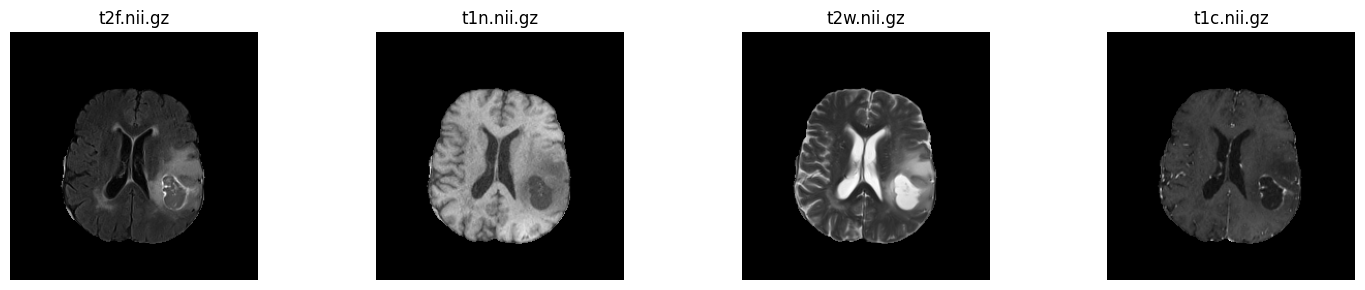

In [10]:
# NOTE: You do not need to implement any code in this cell, it is provided for you!
# Collect all image files (excluding the mask)
path_to_image_files = [os.path.join(EXAMPLE_PATH, f) for f in files_in_example_dir if "seg" not in f]

# Create new figure with subplots
fig, axes = plt.subplots(1, len(path_to_image_files), figsize=(15, 3))


# We are going to use the following function to load NIfTI files in the correct orientation
def load_nifti_file(file_path):
    """Helper function that loads a NIfTI file and return the data array."""
    nii = nib.load(file_path)
    data = nii.get_fdata()

    # Flip the image vertically
    data = np.flip(data, axis=0).copy()

    return data

# Loop through files
for i, file in enumerate(path_to_image_files):
    # Load NIfTI file
    data = load_nifti_file(file)

    # Display the slice
    axes[i].imshow(data, cmap='gray')
    axes[i].set_title(os.path.basename(file))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

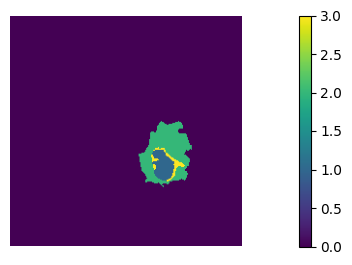

In [11]:
# NOTE: You do not need to implement any code in this cell, it is provided for you!
# Visualize the mask file
mask_path = os.path.join(EXAMPLE_PATH, "seg.nii.gz")

# Display the mask
fig, ax = plt.subplots(figsize=(15, 3))
cax = ax.imshow(load_nifti_file(mask_path))
ax.axis('off')
fig.colorbar(cax, ax=ax)
plt.show()

### `Question 1.1` (5 points)

As we can see above, the segmentation masks in this dataset have four classes. Explain the corresponding concept for each label value. Refer to the BraTS 2023 documentation, which can be found here: [https://www.synapse.org/Synapse:syn51156910/wiki/622351](https://www.synapse.org/Synapse:syn51156910/wiki/622351)

<span style='color:green;'> YOUR ANSWER HERE </span>


# 2 | Introduction to Pytorch
![](https://miro.medium.com/v2/resize:fit:512/1*IMGOKBIN8qkOBt5CH55NSw.png)

PyTorch is an open-source machine learning library developed by Facebook's AI Research lab (FAIR) that has gained significant adoption in both academic research and industry applications. It provides a comprehensive ecosystem for deep learning model development, training, and deployment.


In this assignment, we will walk through various Pytorch classes that make model development easy!

## Datasets 📊

The Dataset class is a cornerstone of PyTorch's data handling architecture that provides a standardized interface for accessing and processing data. This abstraction layer serves as the foundation for efficient data management during model training and evaluation.


Core Functionality
At its essence, the Dataset class is an abstract class that requires implementation of two key methods:

- __len__() - Returns the total number of samples in the dataset
- __getitem__(index) - Retrieves a specific sample by its index

An implementation of simple Dataset class is provided below:

In [12]:
#@title Dataset Implementation

class SegmentationDataset(torch.utils.data.Dataset):

  def __init__(self, directory_path, binary_mask=True):
    """
    Intializes the dataset given the path to the dataset directory.
    """
    self.directory_path = directory_path
    self.example_list = json.load(open(os.path.join(directory_path, f"index.json"), "r"))
    self.binary_mask = binary_mask

  def __len__(self):
    return len(self.example_list)

  def __getitem__(self, index):
    """
    Defines how to retrieve a specific example from the dataset using the index.
    """

    # Image Data filename
    image_filename = "t2w.nii.gz"

    # Mask Data filename
    mask_filename = "seg.nii.gz"

    path_to_example_dir = os.path.join(self.directory_path, self.example_list[index])

    # Load in the mask for the example
    mask = load_nifti_file(os.path.join(path_to_example_dir, mask_filename))

    # If we are using a binary mask, collapse non-zero values to 1
    if self.binary_mask:
      mask = np.where(mask > 0, 1, 0)

    return {
        "image": np.expand_dims(load_nifti_file(os.path.join(path_to_example_dir,image_filename)),axis=0),
        "mask" : mask
    }


In [13]:
train_dataset = SegmentationDataset(os.path.join(DATA_PATH, "train"))
val_dataset = SegmentationDataset(os.path.join(DATA_PATH, "val"))

### `Question 2.1` (5 points)

In the SegmentationDataset implementation above, we are loading the image and mask data as numpy arrays, which are then placed into a dictionary for easy access.


In the following cell, index into the dataset to get the first example. What is the shape of the data within the "image" and "mask" keys?

In [23]:
# TODO: Implement code in this cell to answer the question above. You should only need a few lines of code to do this.
train_example = train_dataset.__getitem__(0)
train_image = train_example.get("image")
train_mask = train_example.get("mask")
print(f'Train image: {train_image.shape}')
print(f'Train Mask: {train_mask.shape}')
validate_example = val_dataset.__getitem__(0)
train_image = validate_example.get("image")
train_mask = validate_example.get("mask")
print(f'Validate image: {train_image.shape}')
print(f'Validate Mask: {train_mask.shape}')

Train image: (1, 240, 240)
Train Mask: (240, 240)
Validate image: (1, 240, 240)
Validate Mask: (240, 240)


## DataLoaders 🏗️

The DataLoader is a crucial component in PyTorch's data handling pipeline that builds upon the Dataset class to provide efficient, batched data processing for model training and evaluation. While the Dataset class defines how individual data samples are accessed, the DataLoader manages how these samples are organized and delivered to the model during the training process.

In [24]:
train_dataloader = DataLoader(dataset= train_dataset, batch_size = 2, shuffle=True)
val_dataloader = DataLoader(dataset= val_dataset, batch_size = 2, shuffle=False)

### `Question 2.2` (5 points)

One of the key features of the DataLoader is it's ability to batch data, which is handled for you by the DataLoader class. Batching is a technique used to improve the efficiency of model training by processing multiple samples at once. The dataloader also converts the data from numpy arrays to tensors, which are more efficient for model training.

In the cell below, determine the shape of the data in the first batch of the training dataloader. Note that you can't access the first batch directly by indexing into the dataloader - you may need to set up a loop that you can terminate early!

In [32]:
# TODO: Implement code in this cell to answer the question above
train_data_iterator = iter(train_dataloader)
train_data_first_batch = next(train_data_iterator)
first_batch_image = train_data_first_batch.get('image')
first_batch_mask = train_data_first_batch.get('mask')
print(f'First batch image: {first_batch_image.shape}')
print(f'First batch mask: {first_batch_mask.shape}')

First batch image: torch.Size([2, 1, 240, 240])
First batch mask: torch.Size([2, 240, 240])


## Models 🤖

PyTorch's central functinality revolves arround neural networks, which are implemented utilizing the `torch.nn.Module` class. This class abstracts the complexities of model development by offering a structured approach to defining network components and their interactions.

The nn.Module serves as a base class from which all neural network components inherit. It provides several critical functionalities:

- Parameter Management: Automatically tracks and registers all learnable parameters.
- Nested Structures: Supports hierarchical organization of network components.
- Forward Propagation: Defines the computation performed during the forward pass.
- Device Management: Facilitates moving model components between CPU and GPU.

### U-Net

In this assignment, we will be implementing a U-Net architecture. The U-Net architecture represents a significant advancement in neural network design for biomedical image segmentation. Originally introduced in 2015, U-Net was specifically developed to address the challenges of medical image analysis. Its distinctive U-shaped architecture provides an elegant solution for precise segmentation tasks where boundary accuracy is critical.


#### The U-Net Architecture
U-Net's design consists of two primary paths:
1. a contracting path (encoder)
2. an expansive path (decoder)

The paths are connected by skip connections. This structure resembles the letter "U" when visualized, hence the name.

The original UNet architecture is visualized in the image shown below:

<div style="text-align: center;">
    <img src="https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png" width="500" height="333" alt="Description of image">
</div>

We won't go into more details about U-Net architectures in this course, but if you're interested in learning more, you can check out the following resources:
- [Stanford's CS 231n](https://cs231n.github.io/convolutional-networks/)
- [U-Net: A complete guide](https://www.geeksforgeeks.org/u-net-architecture-explained/)

In [33]:
#@title U-Net Architecture Implementation
# NOTE: You do not need to change any code in this cell, it is provided for you!


def conv(in_channels, out_channels):
    """
    Defines a convolutional block with a convolution, batch normalization, and a ReLU activation function.
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )


def up_conv(in_channels, out_channels):
    """
    Defines an up-convolutional block with a transposed convolution and a ReLU activation function.
    """
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
        nn.ReLU(inplace=True)
    )


class UNet(nn.Module):
    """
    Defines the U-Net architecture. We will use a pretrained VGG16 model as the encoder
    """
    def __init__(self, in_channels=1, out_channels=2):
        """
        Initializes the U-Net architecture.

        Args:
            in_channels (int): The number of channels in the input image.
            out_channels (int): The number of channels in the output mask.
        """
        super().__init__()

        assert out_channels >= 2, "Output channels should be at least 2"

        self.input_norm = nn.InstanceNorm2d(in_channels, affine=True, track_running_stats=True)

        # Use pretrained VGG16 with batch normalization as the encoder
        self.encoder = vgg16_bn(weights="VGG16_BN_Weights.DEFAULT").features

        # We modify the in_channels to accept a grayscale image
        self.encoder[0] = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1)

        # Divide encoder into blocks
        self.block1 = nn.Sequential(*self.encoder[:6])   # Output: 64 channels
        self.block2 = nn.Sequential(*self.encoder[6:13])  # Output: 128 channels
        self.block3 = nn.Sequential(*self.encoder[13:20]) # Output: 256 channels
        self.block4 = nn.Sequential(*self.encoder[20:27]) # Output: 512 channels
        self.block5 = nn.Sequential(*self.encoder[27:34]) # Output: 512 channels

        # Add a bottleneck convolution to increase feature depth
        self.bottleneck_conv = conv(512, 1024)

        # Decoder path
        self.up_conv6 = up_conv(1024, 512)
        self.conv6 = conv(512 + 512, 512)  # Skip connection with block4

        self.up_conv7 = up_conv(512, 256)
        self.conv7 = conv(256 + 256, 256)  # Skip connection with block3

        self.up_conv8 = up_conv(256, 128)
        self.conv8 = conv(128 + 128, 128)  # Skip connection with block2

        self.up_conv9 = up_conv(128, 64)
        self.conv9 = conv(64 + 64, 64)    # Skip connection with block1

        # Final convolution to get the desired number of output channels
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):

        # Normalize input channels separately
        x = self.input_norm(x)

        # Encoder path
        block1 = self.block1(x)         # Output size: ~240x240
        block2 = self.block2(block1)    # Output size: ~120x120
        block3 = self.block3(block2)    # Output size: ~60x60
        block4 = self.block4(block3)    # Output size: ~30x30
        block5 = self.block5(block4)    # Output size: ~15x15

        # Use block5 as our bottleneck
        x = self.bottleneck_conv(block5)  # Output: 1024 channels, ~15x15

        # Decoder path with skip connections
        x = self.up_conv6(x)              # Output: 512 channels, ~30x30
        x = torch.cat([x, block4], dim=1)
        x = self.conv6(x)

        x = self.up_conv7(x)              # Output: 256 channels, ~60x60
        x = torch.cat([x, block3], dim=1)
        x = self.conv7(x)

        x = self.up_conv8(x)              # Output: 128 channels, ~120x120
        x = torch.cat([x, block2], dim=1)
        x = self.conv8(x)

        x = self.up_conv9(x)              # Output: 64 channels, ~240x240
        x = torch.cat([x, block1], dim=1)
        x = self.conv9(x)

        # Final output
        x = self.final_conv(x)

        return x


In [34]:
# Run this cell to load the model
model = UNet()

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:09<00:00, 58.8MB/s]


Models in pytorch are defined as classes that inherit from the `torch.nn.Module` class, and are composed of multiple sub-modules. Run the following cell to see a printout of the model's architecture which includes the names of all submodules.

In [35]:
print(model)

UNet(
  (input_norm): InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Ma

We can also access the sub-modules individually using dot notation as follows:

In [36]:
model.final_conv

Conv2d(64, 2, kernel_size=(1, 1), stride=(1, 1))

We can even see the individual weights and biases within modules:

In [37]:
print(f"Shape of weights in final conv layer: {model.final_conv.weight.shape}")
print(f"Shape of biases in final conv layer: {model.final_conv.bias.shape}")

Shape of weights in final conv layer: torch.Size([2, 64, 1, 1])
Shape of biases in final conv layer: torch.Size([2])


### `Question 2.3` (5 points)

How many parameters does this U-Net model have? Use the following cell to calculate the number of parameters.
(Hint: You may find the torch function `model.parameters()` useful)

In [41]:
# TODO: Implement code in this cell to answer the question above
param_count = 0
for param in model.parameters():
  param_count += 1
  print(f'{param_count}: Shape: {param.shape()}')

print(f'Total of {param_count} found for the U-Net model')



Streaming output truncated to the last 5000 lines.
          [ 0.0089,  0.0008, -0.0133]],

         [[ 0.0152, -0.0027,  0.0033],
          [ 0.0086, -0.0325,  0.0049],
          [-0.0100, -0.0073,  0.0257]],

         ...,

         [[ 0.0431,  0.0533,  0.0326],
          [ 0.0395,  0.0611,  0.0268],
          [ 0.0073,  0.0205, -0.0029]],

         [[ 0.0094, -0.0241, -0.0428],
          [ 0.0194, -0.0138, -0.0492],
          [ 0.0160,  0.0069, -0.0044]],

         [[ 0.0276,  0.0157, -0.0280],
          [ 0.0373,  0.0051, -0.0387],
          [ 0.0207, -0.0125, -0.0327]]],


        ...,


        [[[-0.0052, -0.0174, -0.0047],
          [ 0.0056,  0.0070,  0.0095],
          [ 0.0014,  0.0072, -0.0012]],

         [[-0.0129, -0.0019,  0.0104],
          [-0.0217, -0.0155,  0.0046],
          [-0.0062,  0.0200,  0.0136]],

         [[ 0.0273,  0.0369, -0.0068],
          [ 0.0312,  0.0206, -0.0170],
          [-0.0376, -0.0369, -0.0333]],

         ...,

         [[ 0.0012,  0.0119,

## Training 🏋️‍♀️
Let's train our U-Net model to segment these brain scan slices. In the cells below, we define a few more things that we will need.

### Loss Function
A loss function is a method of measuring how well a machine learning model performs by quantifying the difference between the model's predictions and the actual target values. It serves as a crucial metric for optimization during training.

For this model, we will define a custom "UnetLoss" function that calculates the Cross Entropy Loss for the mask.

In [ ]:
#@title Loss Function
# NOTE: You do not need to change any code in this cell

ce = nn.CrossEntropyLoss()

def UnetLoss(preds: torch.Tensor, targets: torch.Tensor):
    """
    Defines a Cross-Entropy loss objective for this U-Net model.

    Args:
        preds (torch.Tensor): Output from the U-Net Model (B, C, H, W)
        targets (torch.Tensor): The target mask the model is trying to predict (B, H, W)

    Returns:
        ce_loss: The cross entropy loss between predictions and targets
        acc: The accuracy, calculated as the mean of correctly classified pixels
    """
    ce_loss = ce(preds, targets)
    acc = (torch.max(preds, 1)[1] == targets).float().mean()
    return ce_loss, acc

### Training Engine

We will also need to implement some functions that apply the loss to each batch of data. We will define these functions as part of the following 'Engine' class.

In [ ]:
#@title Training Engine
# NOTE: You do not need to change any code in this cell
class engine():
  def train_batch(model, data, optimizer, criterion,config):
      model.train()

      ims, mask = data["image"], data["mask"]

      # Move images and masks to the device
      ims = ims.to(config.DEVICE).float()
      mask = mask.to(config.DEVICE).long()

      predicted_mask = model(ims)
      optimizer.zero_grad()

      loss, acc = criterion(predicted_mask, mask)
      loss.backward()
      optimizer.step()

      return loss.item(), acc.item()

  @torch.no_grad()
  def validate_batch(model, data, criterion, config):
      model.eval()

      ims, mask = data["image"], data["mask"]

      ims = ims.to(config.DEVICE).float()
      mask = mask.to(config.DEVICE).long()

      predicted_mask = model(ims)

      loss, acc = criterion(predicted_mask, mask)

      return loss.item(), acc.item()

### Config
Finally, it is always important to set up a config for hyper-parameters and other
settings that we may want to change in subsequent training runs. To do this, lets
set up a simple class to store various configuration settings as attributes.

In [ ]:
#@title Config
class config:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    LEARNING_RATE = 1e-3
    N_EPOCHS = 2
    eval_steps = 100

In [ ]:
# Set up the loss function and optimizer
criterion, optimizer = UnetLoss, optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# Move the model to the device
model.to(config.DEVICE)

print("Ready to go!")


The following cells will define the training loop for the model. We have implemented TensorBoard logging for you, so you will be able to visualize the training process.

In [ ]:
# NOTE: You do not need to change any code in this cell

def run(model, train_dataloader, val_dataloader, checkpoint_name = "best_model.pth"):

    # Move the model to the device
    model.to(config.DEVICE)

    # Initialize TensorBoard writer
    writer = SummaryWriter(None)

    # Track metrics across epochs
    best_val_loss = float('inf')

    for epoch in range(config.N_EPOCHS):
        print("####################")
        print(f"       Epoch: {epoch}   ")
        print("####################")

        # Initialize metrics for this epoch
        epoch_train_loss = 0.0
        epoch_train_acc = 0.0

        # Training phase
        model.train()
        train_loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), desc=f"Train - Epoch {epoch}")

        for bx, data in train_loop:
            train_loss, train_acc = engine.train_batch(model, data, optimizer, criterion, config)

            # Update running metrics
            epoch_train_loss += train_loss
            epoch_train_acc += train_acc

            # Update progress bar
            train_loop.set_description(f"Train - Epoch {epoch}, Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

            # Log batch metrics
            global_step = epoch * len(train_dataloader) + bx
            writer.add_scalar('Batch/train_loss', train_loss, global_step)
            writer.add_scalar('Batch/train_accuracy', train_acc, global_step)

            if bx % config.eval_steps == 0 and bx != 0:
                best_val_loss = evaluate(model, val_dataloader, writer, epoch, best_val_loss, checkpoint_name)

        # Calculate average metrics for the epoch
        avg_train_loss = epoch_train_loss / len(train_dataloader)
        avg_train_acc = epoch_train_acc / len(train_dataloader)

        writer.add_scalar('Epoch/train_loss', avg_train_loss, epoch)
        writer.add_scalar('Epoch/train_accuracy', avg_train_acc, epoch)


        # Close the TensorBoard writer
        writer.close()

def evaluate(model, val_dataloader, writer, epoch, best_val_loss, checkpoint_name):

        epoch_val_loss = 0.0
        epoch_val_acc = 0.0

        # Validation phase
        model.eval()
        val_loop = tqdm(enumerate(val_dataloader), total=len(val_dataloader), desc=f"Val")

        for bx, data in val_loop:
            val_loss, val_acc = engine.validate_batch(model, data, criterion, config)

            # Update running metrics
            epoch_val_loss += val_loss
            epoch_val_acc += val_acc

            # Update progress bar
            val_loop.set_description(f"Val - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        # Calculate average metrics for the epoch
        avg_val_loss = epoch_val_loss / len(val_dataloader)
        avg_val_acc = epoch_val_acc / len(val_dataloader)

        # Log epoch metrics to TensorBoard
        writer.add_scalar('Epoch/val_loss', avg_val_loss, bx)
        writer.add_scalar('Epoch/val_accuracy', avg_val_acc, bx)

        # Save model if validation loss improves
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
            }, os.path.join(DATA_PATH, checkpoint_name))
            print(f">>>*** New best model checkpoint saved with val_loss: {avg_val_loss:.4f}***<<<")

        print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

        return best_val_loss


In [ ]:
# Launch TensorBoard in Colab
# NOTE: You do not need to change any code in this cell
display(Javascript("""
(async function() {
    const url = await google.colab.kernel.proxyPort(6006, {'cache': true});
    document.querySelector("#output-area").appendChild(document.createElement("div")).innerHTML = `
    <div style="padding: 10px; margin: 10px 0; background-color: #f8f9fa; border-radius: 4px; text-align: center;">
        <p><strong>TensorBoard is running!</strong></p>
        <p>View it here: <a href="${url}" target="_blank">${url}</a></p>
    </div>
    `;
})();
"""))
tb.notebook.start("--logdir runs")

In [ ]:
#@title Train

# Use this boolean to toggle whether you want to run the training engine
force_run = True
if force_run or not os.path.exists(os.path.join(DATA_PATH, 't2w_best_model.pth')):
    run(model, train_dataloader, val_dataloader, checkpoint_name = "t2w_best_model.pth")

### `Question 2.4` (5 points)
Review the code above. Describe the training process and answer the following questions:
- How often is the model validated?
- What is an 'epoch' in the context of model training?

# Inference
Now that we have trained our model, we can use it to make predictions!

First, let's load in the checkpoint that achieved the lowest validation loss on the validation set.

In [ ]:
# First, let's load the best model and move it to the device
# - You will only be able to load the checkpoint when you have trained the model using the previous cell
# NOTE: You do not need to change any code in this cell
model.load_state_dict(torch.load(os.path.join(DATA_PATH, 't2w_best_model.pth'))['model_state_dict'])
model.to(config.DEVICE)
print("Best model checkpoint loaded")

In [ ]:
# NOTE: You do not need to change any code in this cell, it is provided for you!
def get_predicted_mask(model: torch.nn.Module, image: Union[np.ndarray, torch.Tensor]):
    """
    Returns the predicted mask by running a given image through the model.

    Args:
        model (torch.nn.Module): The trained U-Net model
        image (np.ndarray): A numpy image of shape (inC, H, W)

    Returns:
        pred_mask (torch.Tensor): The predicted mask for the image (H, W)
    """
    model.eval()
    with torch.no_grad():
        # Convert the image to a tensor to run through the model (inC, H, W) -> (1, inC, H, W)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0).to(config.DEVICE)

        # Run the image through the model
        logits = model(image)

        # Convert the predicted mask to a numpy array (1, outC, H, W) -> (1, H, W)
        pred_mask = torch.argmax(logits, dim=1)

        # Convert the predicted mask to a numpy array (1, H, W) -> (H, W)
        return pred_mask.cpu().numpy().squeeze()

def visualize_prediction(image, mask, predicted_mask):
    """
    Visualizes a given image, mask, and predicted mask as color overlays.

    Args:
        image (np.ndarray): The image to visualize (H, W)
        mask (np.ndarray): The ground truth mask (H, W)
        predicted_mask (np.ndarray): The predicted mask from the model (H, W)
    """
    # Create a figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Handle case where image has an extra dimension
    if image.ndim == 3:
        image = image[0]

    # Plot the original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Create overlay for ground truth mask
    axes[1].imshow(image, cmap='gray')
    mask_rgba = plt.cm.viridis(mask / mask.max())  # Convert to RGBA using viridis colormap
    mask_rgba[..., 3] = 0.5  # Set alpha for transparency
    axes[1].imshow(mask_rgba)
    axes[1].set_title('Ground Truth Overlay')
    axes[1].axis('off')

    # Create overlay for predicted mask
    axes[2].imshow(image, cmap='gray')
    pred_rgba = plt.cm.viridis(predicted_mask / predicted_mask.max())  # Convert to RGBA
    pred_rgba[..., 3] = 0.5  # Set alpha for transparency
    axes[2].imshow(pred_rgba)
    axes[2].set_title('Prediction Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Let's try an image from the validation set
# NOTE: You do not need to change any code in this cell, it is provided for you!
predicted_mask = get_predicted_mask(model, val_dataset[0]["image"])
visualize_prediction(val_dataset[0]["image"], val_dataset[0]["mask"], predicted_mask)

### `Question 2.5` (5 points)

How does the predicted mask compare to the ground truth mask? Does the model seem to perform well on this image?

<span style='color:green;'> YOUR ANSWER HERE </span>


# 3 | Evaluation
Now let's set up some methods to evaluate the predictions of our model. In this part of the assignment, you will be responsible for implementing functions to calculate various evaluation metrics. Let's dive in!

In [ ]:
# The following function is provided for you to retrieve the model's predictions
def get_batch_predictions(model: torch.nn.Module, batch: dict):
    """
    Returns the predicted mask by running a given batch of images through the model.

    Args:
        model (torch.nn.Module): The trained U-Net model
        batch (dict): A dictionary containing the batch of images of shape (B, inC, H, W)


    Returns:
        pred_masks (torch.Tensor): The predicted masks for the batch of images (B, H, W)
        probs (torch.Tensor): The probabilities of the predicted masks for the batch of images (B, H, W)
    """
    model.eval()

    with torch.no_grad():
        # Collect the input images
        input_images = batch["image"].to(config.DEVICE).float()

        # Run the input images through the model
        logits = model(input_images)

        # Get the predicted masks
        pred_masks = torch.argmax(logits, dim=1)

        # Get the probabilities of the predicted masks
        probs = torch.softmax(logits, dim=1)[:, 1, :, :]

    return pred_masks, probs


# We will also pull the following data from the batch to make it easier to develop your functions
for batch in val_dataloader:
    example_target_mask = batch["mask"]
    example_predicted_masks, example_probs = get_batch_predictions(model, batch)
    break

# Let's take a look:

# The target mask is a tensor of shape (B, H, W) which contains the integer labels for each pixel in the image
print(f"Example target mask: {example_target_mask.shape}") # (B, H, W)
print(example_target_mask[0])

# The predicted masks are a tensor of shape (B, H, W) which contains the PREDICTED integer labels for each pixel in the image
print(f"Example predicted masks: {example_predicted_masks.shape}") # (B, H, W)
print(example_predicted_masks[0])

# The probabilities are a tensor of shape (B, H, W) which contains the probabilities of the predicted masks for each pixel in the image
# - Given that we are using a binary mask, the probabilities are the probabilities of the predicted mask being 1
print(f"Example probabilities: {example_probs.shape}") # (B, H, W)
print(example_probs[0])


### Dice Score 🎲

The DICE score (also known as the DICE similarity coefficient or DSC) is one of the most commonly used metrics for evaluating the performance of image segmentation models.

#### What is the DICE Score?

The DICE score measures the overlap between two sets: the predicted segmentation mask and the ground truth mask. It is particularly useful for segmentation tasks because:

1. It's sensitive to the overlap between the prediction and ground truth
2. It handles class imbalance well (when the foreground object is much smaller than the background)
3. It's intuitive to understand as a measure of similarity

#### Mathematical Definition

The DICE coefficient is mathematically defined as:

$$\text{DICE} = \frac{2 \times |X \cap Y|}{|X| + |Y|}$$

Where:
- $X$ is the set of pixels in the predicted segmentation mask
- $Y$ is the set of pixels in the ground truth mask
- $|X \cap Y|$ represents the number of pixels common to both masks (the intersection)
- $|X|$ and $|Y|$ represent the number of pixels in each mask

### `Question 3.1` (10 points) - Dice Score Implementation

Implement the Dice score function below as specified in the instructions.

In [ ]:
def calculate_dice_score(target_masks: torch.Tensor, predicted_masks: torch.Tensor) -> torch.Tensor:
    """
    Calculates the Dice score between the target masks and the predicted masks.

    TODO: You should implement this function where specified below.

    Args:
        target_masks (torch.Tensor): The target masks of shape (H, W)
        predicted_masks (torch.Tensor): The predicted masks of shape (H, W)

    Returns:
        dice_scores (torch.Tensor): The Dice score for the image/mask pair
    """

    # Ensure the target masks and predicted masks are on the same device
    target_masks = target_masks.to("cpu")
    predicted_masks = predicted_masks.to("cpu")

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return dice_scores

In [ ]:
# Sanity checks for the your Dice score function
dice_score = calculate_dice_score(example_target_mask[0, :, :], example_predicted_masks[0, :, :])
print(f"Dice score: {dice_score}")

## Hausdorff Distance 📐

Unfortunately, the DICE score is somewhat hard to interpret. To address this, we can use the Hausdorff distance, which is a more interpretable metric for evaluating the performance of a segmentation model.

#### What is the Hausdorff Distance?

The [Hausdorff distance](https://en.wikipedia.org/wiki/Hausdorff_distance) measures the maximum distance from any point in the predicted mask to the nearest point in the ground truth mask. Think of it as the "worst-case scenario" distance between boundaries.

### Question 3.2 (10 points) - Hausdorff Distance Implementation

Implement the Hausdorff distance function below as specified in the instructions.

In [ ]:
#@title Dice Score Implementation: 20 points

from scipy.spatial.distance import directed_hausdorff


def calculate_hausdorff_distance(target_masks: torch.Tensor, predicted_masks: torch.Tensor) -> torch.Tensor:
    """
    Calculates the Hausdorff distance between the target masks and the predicted masks.

    TODO: You should implement this function where specified below.

    IMPLEMENTATION INSTRUCTIONS:
    - If both masks are empty (do not contain any non-zero pixels), your implementation should return 0.0.
    - If one mask is empty and the other is not, your implementation should return infinity.
    - Otherwise, your implementation should calculate the Hausdorff distance in both directions
        (from predicted mask to target mask and from target mask to predicted mask) using the
        `directed_hausdorff` function imported above and return the maximum of the two values.

    Args:
        target_masks (torch.Tensor): The target masks of shape (H, W)
        predicted_masks (torch.Tensor): The predicted masks of shape (H, W)

    Returns:
        hausdorff_dist (torch.Tensor): The Hausdorff distance for the image/mask pair
    """

    # Ensure the target masks and predicted masks are on the same device
    target_masks = target_masks.to("cpu")
    predicted_masks = predicted_masks.to("cpu")

    # Convert tensors to numpy arrays for directed_hausdorff function
    target_np = target_masks.detach().numpy()
    pred_np = predicted_masks.detach().numpy()

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return hausdorff_dist

In [ ]:
hausdorff_distance = calculate_hausdorff_distance(example_target_mask[0, :, :], example_predicted_masks[0, :, :])
print(f"Hausdorff distance: {hausdorff_distance}")

### `Question 3.3` (5 points)

If each pixel in the slices above is 1mm x 1mm, what does the Hausdorff distance you calculated above tell us? Would it be reasonable to use this model in a clinical setting where the size of a tumor is 100mm x 100mm? What about 10mm x 10mm?

<span style='color:green;'> YOUR ANSWER HERE </span>



## Binary Metrics 📊

In this set up, we are interested in determining the ability of our model to correctly classify the tumor regions from the background. This can be viewed as a pixel-wise binary classification problem, where for each pixel we decide whether it belongs to the foreground (object of interest) or background.

### The Confusion Matrix: A Foundation for All Metrics
All binary classification metrics start with the confusion matrix, which organizes predictions into four categories:

- True Positives (TP): Pixels correctly predicted as foreground (1)
- True Negatives (TN): Pixels correctly predicted as background (0)
- False Positives (FP): Background pixels *incorrectly* predicted as foreground (1)
- False Negatives (FN): Foreground pixels *incorrectly* predicted as background (0)


### Decision Thresholds
Our model outputs a probability value for each pixel in the image, which we can use to make a prediction for each pixel.
In the binary case, we often define a decision threshold, which is the probability value above which we predict a pixel to be in the foreground (1) and below which we predict a pixel to be in the background (0).



**Let's start by implementing the confusion matrix function below with an optional prediction threshold parameter.**

### `Question 3.4` (10 points) - Confusion Matrix Implementation

Implement the confusion matrix function below as specified in the instructions.


In [ ]:
def calculate_confusion_matrix(target_masks: torch.Tensor, predicted_probs: torch.Tensor, prediction_threshold: float = 0.5) -> torch.Tensor:
    """
    Calculates the confusion matrix between the target masks and the predicted masks for the
    specified prediction threshold.

    TODO: Implement the function where specified below.

    Args:
        target_masks (torch.Tensor): The target masks of shape (H, W)
        predicted_probs (torch.Tensor): The predicted probabilities of the masks of shape (H, W)
        prediction_threshold (float): The threshold to use for the predicted masks

    Returns:
        confusion_matrix (torch.Tensor): The confusion matrix of shape (2, 2)
            Where each confusion matrix is of the form:
                [[TP, FN],
                 [FP, TN]]
    """

    # Ensure the target masks and predicted probabilities are on the same device
    target_masks = target_masks.to("cpu")
    predicted_probs = predicted_probs.to("cpu")

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return confusion_matrix


In [ ]:
# Sanity checks for the your confusion matrix function (We will pass the first image in the batch for now)
confusion_matrix = calculate_confusion_matrix(example_target_mask[0, :, :], example_probs[0, :, :])
print(f"Confusion matrix: {confusion_matrix}")

### Now let's implement some binary metrics!

Implement all of the following functions utilizing the confusion matrix as an input:

### `Question 3.5` (5 points) - Accuracy Implementation

Implement the accuracy function below as specified in the instructions.


In [ ]:
def calculate_accuracy(confusion_matrix: torch.Tensor) -> torch.Tensor:
    """
    Calculates the accuracy from the confusion matrix.

    TODO: Implement the function where specified below.

    Args:
        confusion_matrix (torch.Tensor): The confusion matrix of shape (2, 2)
            with each matrix being [[TP, FN], [FP, TN]]

    Returns:
        accuracy (torch.Tensor): The accuracy
    """

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return accuracy


In [ ]:
accuracy = calculate_accuracy(confusion_matrix)
print(f"Accuracy: {accuracy}")

### `Question 3.6` (10 points) - Precision Implementation

Implement the precision function below as specified in the instructions.


In [ ]:
def calculate_precision(confusion_matrix: torch.Tensor) -> torch.Tensor:
    """
    Calculates the precision from the confusion matrix.

    Precision is defined as TP / (TP + FP). Note, if TP + FP = 0, your implementation should return 0.

    TODO: Implement the function where specified below.

    Args:
        confusion_matrix (torch.Tensor): The confusion matrix of shape (2, 2)
            with each matrix being [[TP, FN], [FP, TN]]

    Returns:
        precision (torch.Tensor): The precision
    """

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return precision


In [ ]:
precision = calculate_precision(confusion_matrix)
print(f"Precision: {precision}")

### `Question 3.7` (10 points) - Recall Implementation

Implement the recall function below as specified in the instructions.


In [ ]:
def calculate_recall(confusion_matrix: torch.Tensor) -> torch.Tensor:
    """
    Calculates the recall from the confusion matrix.

    Recall is defined as TP / (TP + FN). Note, if TP + FN = 0, your implementation should return 0.

    TODO: Implement the function where specified below.

    Args:
        confusion_matrix (torch.Tensor): The confusion matrix of shape (2, 2)
            with each matrix being [[TP, FN], [FP, TN]]

    Returns:
        recall (torch.Tensor): The recall
    """

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return recall

In [ ]:
recall = calculate_recall(confusion_matrix)
print(f"Recall: {recall}")

### `Question 3.8` (10 points) - F1 Score Implementation

Implement the F1 score function below as specified in the instructions.


In [ ]:
def calculate_f1_score(confusion_matrix: torch.Tensor) -> torch.Tensor:
    """
    Calculates the F1 score from the confusion matrix.

    F1 score is defined as 2 * (precision * recall) / (precision + recall)

    NOTE: If precision + recall = 0, your implementation should return 0.

    Args:
        confusion_matrix (torch.Tensor): The confusion matrix of shape (B, 2, 2)
            with each matrix being [[TP, FN], [FP, TN]]

    Returns:
        recall (torch.Tensor): The recall for each image/mask pair within the batch of shape (B,)
    """

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return f1_score

In [ ]:
f1_score = calculate_f1_score(confusion_matrix)
print(f"F1 score: {f1_score}")

Finally, let's use the metrics you implemented to evaluate the performance of your model on the validation set.

In [ ]:
# NOTE: You do not need to modify this cell, it is provided for you!

def calculate_metrics(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader) -> dict:
    """
    Calculate the metrics for the model on the validation set.

    NOTE: We didn't include Hausdorff here because it takes a while to compute
    """

    metrics = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1_score": [],
        "dice_score": [],
    }

    for batch in tqdm(dataloader, total=len(dataloader), desc="Calculating metrics"):
        example_target_mask = batch["mask"]
        example_predicted_masks, example_probs = get_batch_predictions(model, batch)

        # Get the confusion matrix for each image in the batch
        batched_confusion_matrix = torch.stack([calculate_confusion_matrix(example_target_mask[i, :, :], example_probs[i, :, :]) for i in range(example_target_mask.shape[0])])

        # Calculate the metrics for each image in the batch
        metrics["accuracy"].extend([calculate_accuracy(confusion_matrix) for confusion_matrix in batched_confusion_matrix])
        metrics["precision"].extend([calculate_precision(confusion_matrix) for confusion_matrix in batched_confusion_matrix])
        metrics["recall"].extend([calculate_recall(confusion_matrix) for confusion_matrix in batched_confusion_matrix])
        metrics["f1_score"].extend([calculate_f1_score(confusion_matrix) for confusion_matrix in batched_confusion_matrix])
        metrics["dice_score"].extend([calculate_dice_score(example_target_mask[i, :, :], example_predicted_masks[i, :, :]) for i in range(example_target_mask.shape[0])])
    # Calculate the mean of the metrics
    mean_metrics = {key: torch.mean(torch.tensor(value)) for key, value in metrics.items()}

    return mean_metrics

In [ ]:
mean_metrics = calculate_metrics(model, val_dataloader)
for key, value in mean_metrics.items():
    print(f"{key}: {value}")

### `Question 3.9` (5 points)
Based on the metrics you calculated above, how well does our model perform? How do you think we could potentially improve the performance of our model?

<span style='color:green;'> YOUR ANSWER HERE </span>


# `Extra Credit Options`: (+10 points)

We are offering an *optional* 10 extra credit points in this assignment!

You may have noticed that the previous model was only using 1 of the 4 MRI views we have available in the patient data. With some pretty minor modifications, we can use all 4 scans to help improve the model's performance!

For this next part of the assignment, let's implement a version of the dataset and model that utilizes all possible input channels.


Implement these extra credit options below. (Do not override your original work!)

To begin, start by implementing the missing sections of the AllChannelSegmentationDataset class below.

### `EC.1` (+4 points)

Implement the missing sections of the AllChannelSegmentationDataset class below.


In [ ]:
class AllChannelSegmentationDataset(SegmentationDataset):
  """
  A dataset class that utilizes all possible input channels. Note that this is a
  subclass of the SegmentationDataset class, so any functions not implemented here
  will be inherited from the SegmentationDataset class.
  """

  def __getitem__(self, index):
    """
    Defines how to retrieve a specific example from the dataset using the index.

    TODO: Implement this function so that it returns a dictionary with the following keys:
    - "image": a tensor of shape (inC, H, W) that contains the image data
    - "mask": a tensor of shape (H, W) that contains the mask data

    Note: The image data should be a tensor of shape (inC, H, W) where inC is the number of input channels.
    The mask data should be a tensor of shape (H, W) where each pixel is an integer value corresponding to the class of the pixel.

    You may find it helpful to refer to the original SegmentationDataset class for this implementation.

    IMPLEMENTATION NOTES:
    - You will need to load in all 4 possible input images and concatenate them along the first dimension.
    - The order of the channels should be t1w, t1c, t2w, t2f.
    """

    # We have provided the code to load in the mask for you:
    # Path to the example directory
    path_to_example_dir = os.path.join(self.directory_path, self.example_list[index])

    # Load in the mask for the example
    mask = load_nifti_file(os.path.join(path_to_example_dir, "seg.nii.gz"))

    # If we are using a binary mask, collapse non-zero values to 1
    if self.binary_mask:
      mask = np.where(mask > 0, 1, 0)

    # ==================== YOUR CODE HERE ====================

    # TODO: Implement
    pass

    # ==================== YOUR CODE HERE ====================

    return return_dict


In [ ]:
# NOTE: You do not need to modify this cell
# Let's recreate the datasets utilizing your new AllChannelSegmentationDataset class
train_dataset_all_channels = AllChannelSegmentationDataset(os.path.join(DATA_PATH, "train"))
val_dataset_all_channels = AllChannelSegmentationDataset(os.path.join(DATA_PATH, "val"))

print(f"Image shape: {train_dataset_all_channels[0]['image'].shape}")
print(f"Mask shape: {train_dataset_all_channels[0]['mask'].shape}")

In [ ]:
# NOTE: You do not need to modify this cell, it is provided for you!
# Let's recreate the dataloaders
train_dataloader_all_channels = DataLoader(train_dataset_all_channels, batch_size=10, shuffle=True)
val_dataloader_all_channels = DataLoader(val_dataset_all_channels, batch_size=10, shuffle=False)

### `EC.2`  (+6 points)

Implement a version of a UNet model that accepts 4 input channels. You can use the UNet class we provided above, use one from an external library, or implement your own!

- You do not need to achieve any particular performance. Just try to get it to train and run! (This is more for you to explore building with models in PyTorch)

- You may find services like MONAI to be helpful! Check out the [MONAI documentation](https://monai.io/model-zoo.html) for more information.

# End of Assignment 2!


We hope you enjoyed this assignment! Assignment 2 was built by [bviggiano](https://github.com/bviggiano) in Spring of 2025.